In [1]:
import numpy as np
import bayesflow as bf
from pathlib import Path

from benchmark.examples.diffusion.simulators.rdm_4 import RDM

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
np.random.seed(2026)

In [3]:
simulators = [
    RDM(model="m0", keep_params=False),
    RDM(model="m1", keep_params=False),
    RDM(model="m2", keep_params=False),
    RDM(model="m3", keep_params=False),
]

In [4]:
# Each trial contains signed RT and condition: (batch_size, 384, 2).
adapter = (
    bf.adapters.Adapter()
    .as_set(["rt", "conditions"])
    .concatenate(["rt", "conditions"], into="summary_variables")
    .convert_dtype("float64", "float32")
    .rename("model_indices", "inference_variables")
)

In [5]:
workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    adapter=adapter,
    summary_network=bf.networks.DeepSet(summary_dim=12),
    scoring_rules="exponential",
    model_names=["M0", "M1", "M2", "M3"],
    initial_learning_rate=1e-3,
)

In [6]:
val_data = workflow.simulate(1000)

In [7]:
history = workflow.fit_online(epochs=200, num_batches_per_epoch=64, batch_size=256, validation_data=val_data)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 757ms/step - ScoringRuleNetwork/scoring_rule: 2.9755 - loss: 2.9755 - val_ScoringRuleNetwork/scoring_rule: 2.9247 - val_loss: 2.9247
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 906ms/step - ScoringRuleNetwork/scoring_rule: 2.4428 - loss: 2.4428 - val_ScoringRuleNetwork/scoring_rule: 2.0808 - val_loss: 2.0808
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 902ms/step - ScoringRuleNetwork/scoring_rule: 2.1206 - loss: 2.1206 - val_ScoringRuleNetwork/scoring_rule: 2.0595 - val_loss: 2.0595
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 870ms/step - ScoringRuleNetwork/scoring_rule: 2.0226 - loss: 2.0226 - val_ScoringRuleNetwork/scoring_rule: 2.1267 - val_loss: 2.1267
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 856ms/step - ScoringRuleNetwork/scoring_rule: 1.8129 - loss: 1.8129 - val_ScoringRuleNetwork/scoring_rule: 1.7686 - val_loss: 1.7686
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - ScoringRuleNetwork/scoring_rule: 1.6692 - loss: 1.6692 - val_Scorin

INFO:bayesflow:Training completed in 3.16 hours.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 3.06 seconds.


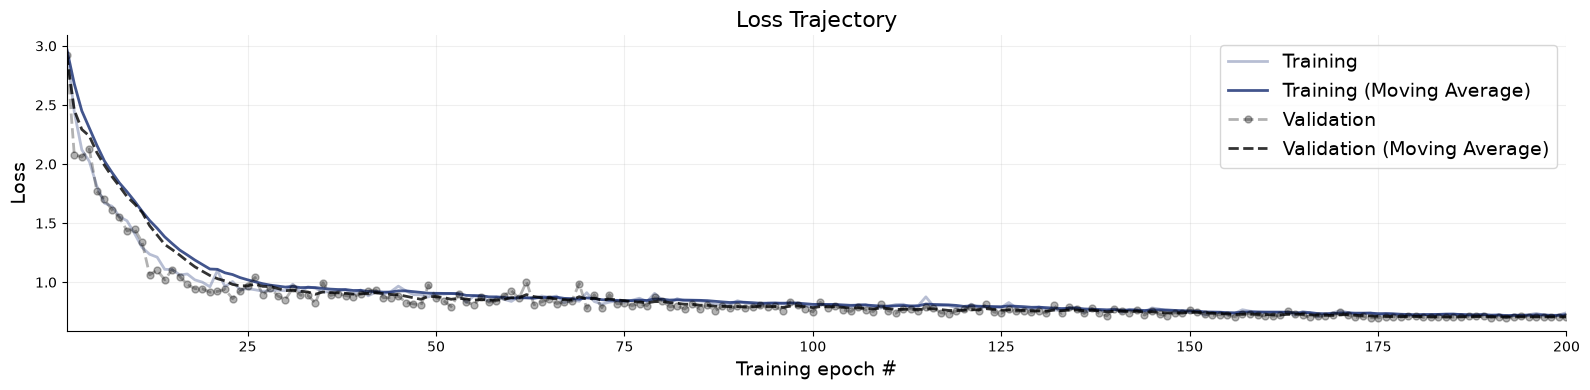

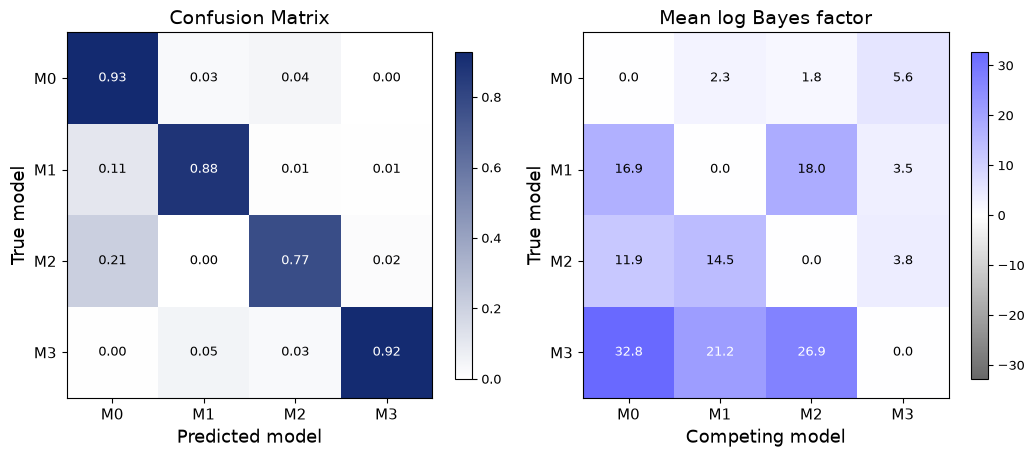

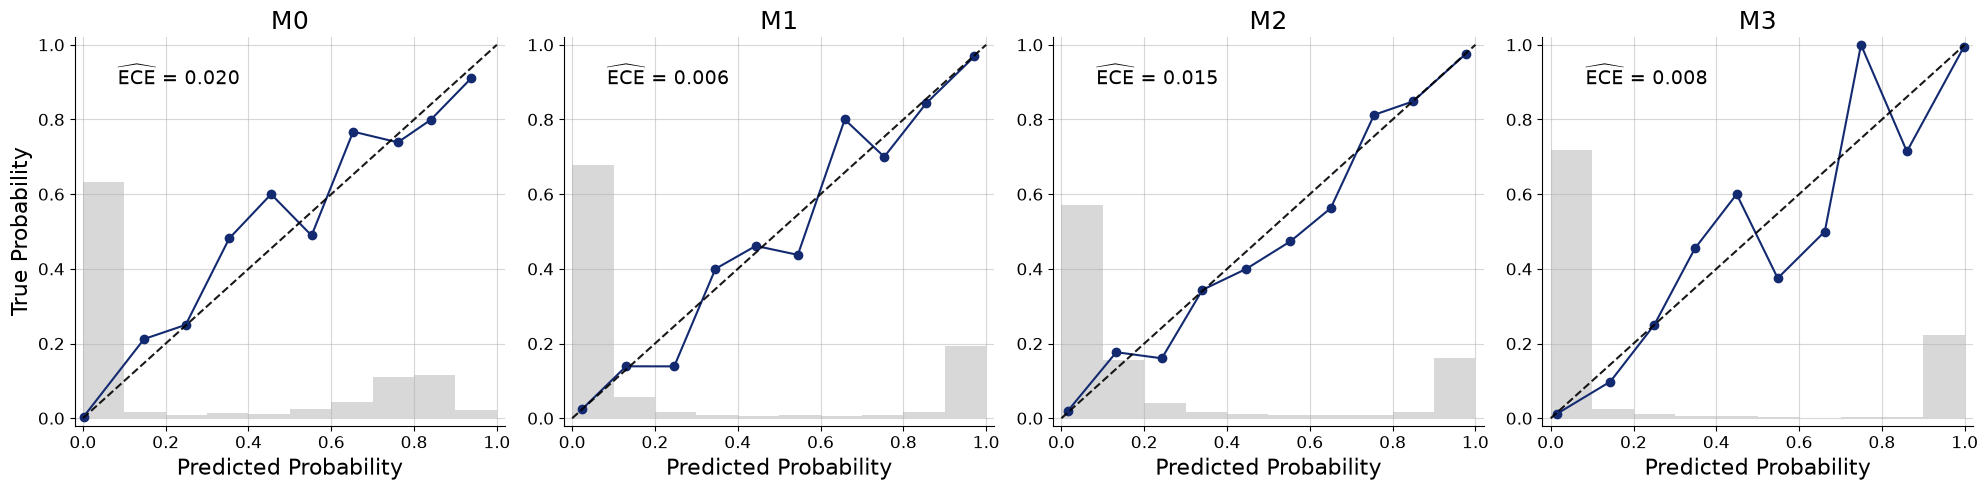

In [8]:
figures = workflow.plot_default_diagnostics(test_data=2000)

In [9]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/direct/direct_exponential.keras")
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)


In [10]:
# Evaluate the saved checkpoint on the shared indirect benchmark.
from benchmark.examples.diffusion.analysis.direct_calibration import ensure_direct_pmp_thresholds
from benchmark.examples.diffusion.analysis.direct_diagnostics import ensure_direct_diagnostics

LOSS = "exponential"
thresholds = ensure_direct_pmp_thresholds(LOSS, checkpoint=filepath)
diagnostics = ensure_direct_diagnostics(LOSS, checkpoint=filepath, indirect_tag="S4D")
print(f"Saved {len(thresholds)} threshold rows and {len(diagnostics)} observed diagnostic rows.")
print(filepath.parent.parent / "results" / "direct" / f"direct_{LOSS}")


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Calibrated exponential on 400 saved diffusion datasets: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_exponential/calibration/thresholds.csv


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Fitting direct_exponential/m0 against the persisted shared raw reference bank


...

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:absl:Epoch 1/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 1:59 8s/step - loss: 17.0273
 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 10.5701
 7/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.2280 
10/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.5833
13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4701
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: -0.6124
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 5.8487 

INFO:absl:Epoch 2/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: -0.6825
 5/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -1.4504
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -3.1809
13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: -2.8442
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -2.5467

INFO:absl:Epoch 3/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: -4.3815
 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -4.0716
 8/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss:

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Saved 2176 observed diagnostic rows for exponential
Saved 4 threshold rows and 2176 observed diagnostic rows.
/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/results/direct/direct_exponential
